# Signal presence by band — which leading indicators are testable where
_Which leading indicators carry mass and variance (are "alive") within each position × minutes band — i.e. which are even testable for association. Leading indicators only; formula inputs are excluded by design. DGW excluded._

**Sections:** (a) liveness by position × band · (b) minutes-gated liveness

---

## Setup
> Whole season, `minutes > 0`, **DGW excluded**; bin minutes into `1-29 / 30-59 / 60+` and run the shared relevance kernel over the leading indicators.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.relevance import (
    compute_relevance, leading_indicator_signals, HIGH_ZERO_MASS_PCT, POSITIONS,
)

POSITIONS = list(POSITIONS)
BANDS = ["1-29", "30-59", "60+"]

try:
    _r = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _r = load_mart()

mart = _r.mart
df = mart[mart["gw"].between(1, _r.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()


def _band(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"


df["band"] = df["minutes"].astype(int).map(_band)
leading = sorted(leading_indicator_signals())
print(f"Study range: GW 1 - {_r.data_cutoff_gw} · minutes > 0 · DGW excluded · n = {len(df):,}")
print(f"Leading indicators ({len(leading)}): {leading}")
print(f"Dead-line: zero-mass >= {HIGH_ZERO_MASS_PCT:.0f}% (or near-zero variance) -> structural_zero")


def _zm_heatmap(ax, piv, title, show_y):
    data = piv.values.astype(float)
    im = ax.imshow(np.ma.masked_invalid(data), cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=100)
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
    if show_y:
        ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
    else:
        ax.set_yticks([])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            txt = f"{v:.0f}" if not np.isnan(v) else "—"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if (np.isnan(v) or v > 60) else "black")
    ax.set_title(title, fontsize=10)
    return im

Study range: GW 1 - 38 · minutes > 0 · DGW excluded · n = 11,190
Leading indicators (11): ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'ict_index', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg', 'xgi']
Dead-line: zero-mass >= 93% (or near-zero variance) -> structural_zero


## (a) Liveness by position × band
> Within each minutes band, which leading indicators are alive at each position?

Zero-mass per (leading indicator, position) in each band, from the shared relevance kernel — green is alive, red is a structural zero (zero-mass >= 93% or near-zero variance), "—" is an empty cell. Attacking signals are absent at GK throughout.

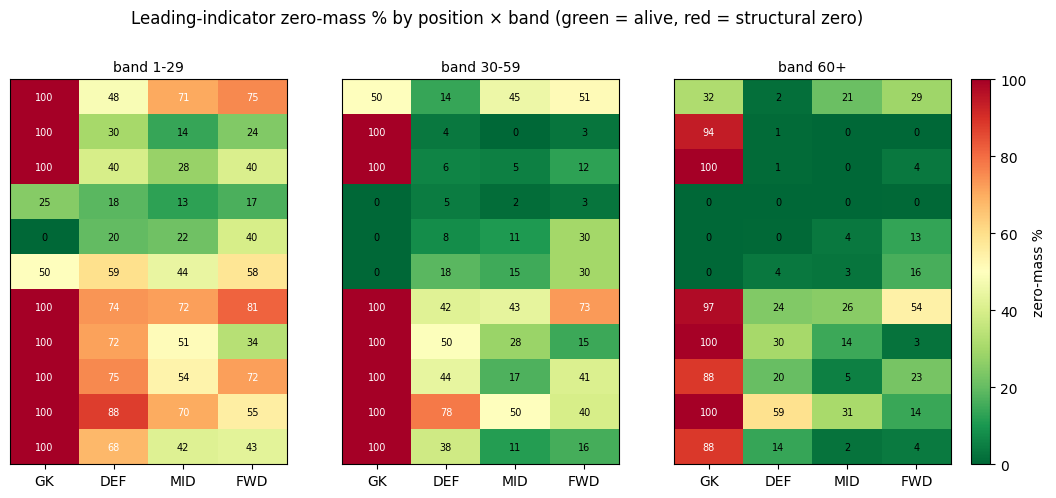

In [2]:
rel = compute_relevance(df, signals=leading, group_cols=["position", "band"])

fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
im = None
for ax, b in zip(axes, BANDS):
    piv = (
        rel[rel["band"] == b]
        .pivot(index="signal", columns="position", values="zero_mass_pct")
        .reindex(index=leading, columns=POSITIONS)
    )
    im = _zm_heatmap(ax, piv, f"band {b}", show_y=(b == BANDS[0]))
fig.suptitle("Leading-indicator zero-mass % by position × band (green = alive, red = structural zero)", y=1.02)
fig.colorbar(im, ax=axes, label="zero-mass %", fraction=0.046, pad=0.02)
plt.show()

## (b) Minutes-gated liveness
> Which signals only become testable once a player clears 60 minutes?

Zero-mass of each leading indicator across the three bands, pooled over outfield positions (DEF / MID / FWD). A signal above the dead-line in 1-29 that drops below it by 60+ is minutes-gated — it needs pitch time to accumulate.

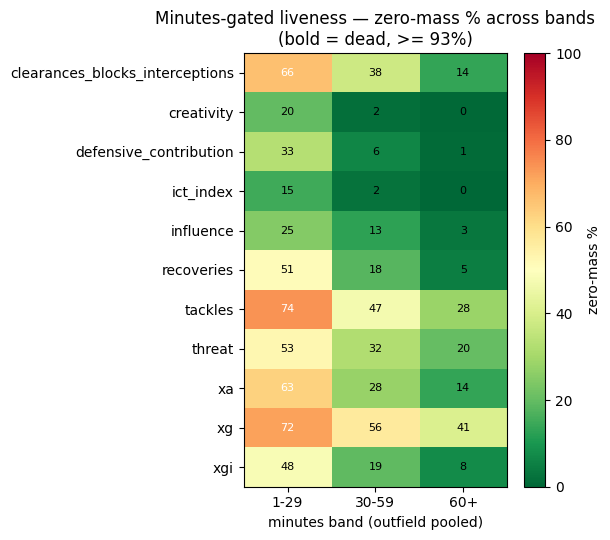

In [3]:
out = df[df["position"].isin(["DEF", "MID", "FWD"])]
relb = compute_relevance(out, signals=leading, group_cols=["band"])
pivb = relb.pivot(index="signal", columns="band", values="zero_mass_pct").reindex(index=leading, columns=BANDS)

fig, ax = plt.subplots(figsize=(6, 5.5))
data = pivb.values.astype(float)
im = ax.imshow(np.ma.masked_invalid(data), cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(BANDS))); ax.set_xticklabels(BANDS)
ax.set_yticks(range(len(leading))); ax.set_yticklabels(leading)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        gated = (not np.isnan(v)) and v >= HIGH_ZERO_MASS_PCT
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                fontweight="bold" if gated else "normal",
                color="white" if (np.isnan(v) or v > 60) else "black")
ax.set_xlabel("minutes band (outfield pooled)")
ax.set_title(f"Minutes-gated liveness — zero-mass % across bands\n(bold = dead, >= {HIGH_ZERO_MASS_PCT:.0f}%)")
fig.colorbar(im, ax=ax, label="zero-mass %")
plt.tight_layout()
plt.show()